In [1]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
import tensorflow as tf
import seaborn as sns
from sklearn.ensemble import IsolationForest
import joblib
os.chdir('Resources/')

In [2]:
df = pd.read_csv('5_Preprocessed_Data.csv')

X = df.drop(['HeartDisease'], axis='columns')
Y = df[['HeartDisease']]

F1-Score for train size 0.1: 0.7605633802816901
F1-Score for train size 0.2: 0.808861119000284
F1-Score for train size 0.3: 0.8293324564288063
F1-Score for train size 0.4: 0.849209409949865
F1-Score for train size 0.5: 0.8830570902394107
F1-Score for train size 0.6: 0.8981001727115717
F1-Score for train size 0.7: 0.9147286821705426
F1-Score for train size 0.8: 0.9413145539906104
F1-Score for train size 0.9: 0.9656862745098039


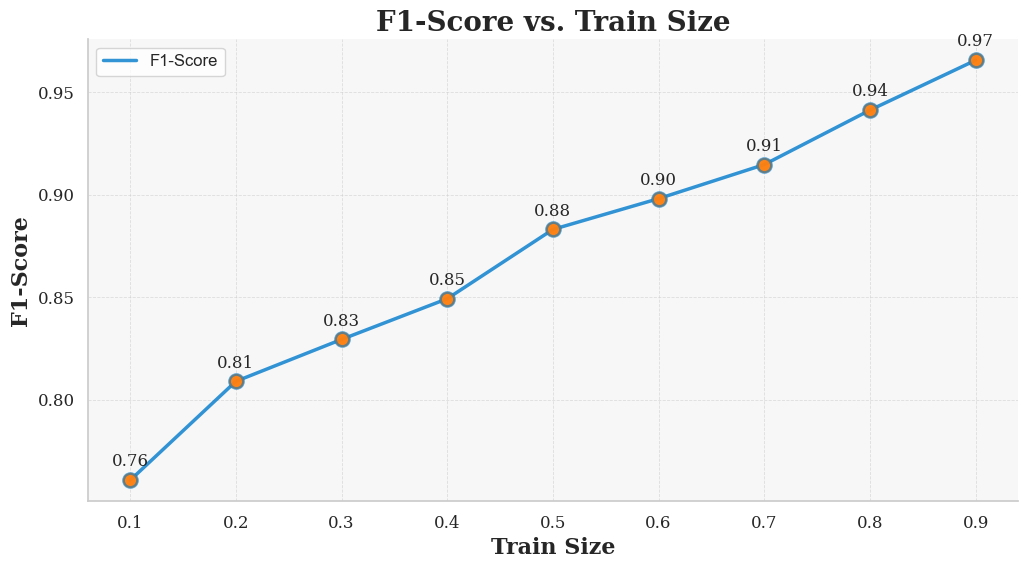

In [3]:
train_sizes = np.linspace(0.1, 0.9, 9)
performances_dtc = []
model_dtc = None

for train_size in train_sizes:
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=4749)
    
    dtc = DecisionTreeClassifier(random_state=436)
    model_dtc = dtc.fit(X_train, Y_train.values.ravel()) 
    
    pred = model_dtc.predict(X_test)
    performance_dtc = f1_score(Y_test, pred)
    
    performances_dtc.append(performance_dtc)
    print(f"F1-Score for train size {train_size:.1f}: {performance_dtc}")

np.savetxt('7_dtc.txt', performances_dtc)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, performances_dtc, linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('F1-Score', fontsize=16, fontweight='bold', family='serif')
plt.title('F1-Score vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(performances_dtc):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], performances_dtc[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['F1-Score'], fontsize=12)

sns.despine()

for i, txt in enumerate(performances_dtc):
    plt.plot(train_sizes[i], performances_dtc[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], performances_dtc[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

F1-Score for train size 0.1: 0.7264684197591545
F1-Score for train size 0.2: 0.7520798668885191
F1-Score for train size 0.3: 0.780069819105046
F1-Score for train size 0.4: 0.8119970738844184
F1-Score for train size 0.5: 0.8302712160979877
F1-Score for train size 0.6: 0.8529729729729729
F1-Score for train size 0.7: 0.8742857142857143
F1-Score for train size 0.8: 0.8794178794178794
F1-Score for train size 0.9: 0.9158110882956879


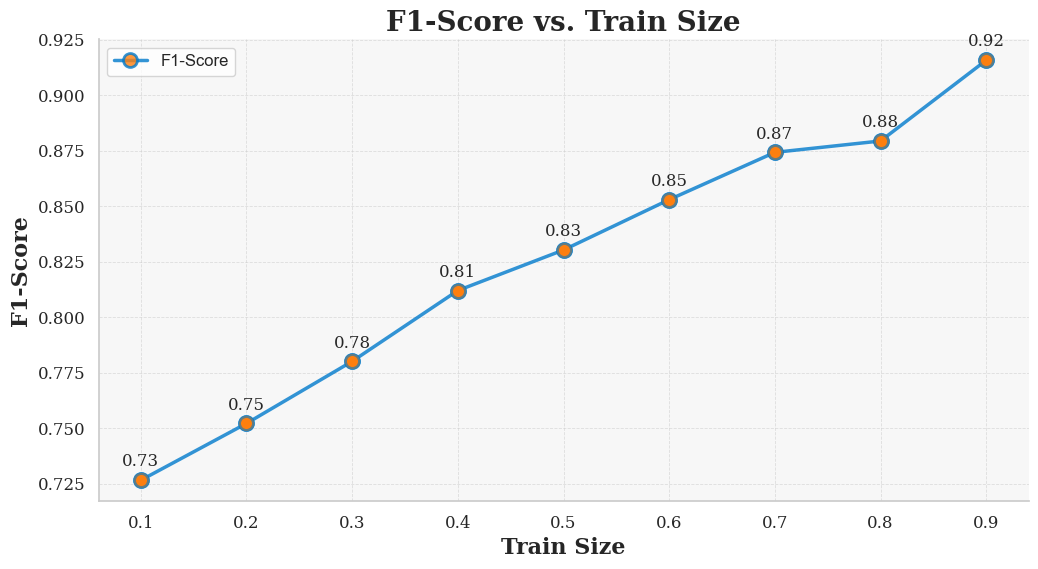

In [4]:
train_sizes = np.linspace(0.1, 0.9, 9)
performances_pca = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=1418)
    
    pca = PCA(n_components=9)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    dtc_pca = DecisionTreeClassifier(random_state=2066)
    dtc_pca.fit(X_train_pca, Y_train.values.ravel())
    
    pred_pca = dtc_pca.predict(X_test_pca)
    performance_pca = f1_score(Y_test, pred_pca)

    performances_pca.append(performance_pca)
    print(f"F1-Score for train size {train_size:.1f}: {performance_pca}")

np.savetxt('7_dtc_pca.txt', performances_pca)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, performances_pca, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('F1-Score', fontsize=16, fontweight='bold', family='serif')
plt.title('F1-Score vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(performances_pca):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], performances_pca[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['F1-Score'], fontsize=12)

sns.despine()

for i, txt in enumerate(performances_pca):
    plt.plot(train_sizes[i], performances_pca[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], performances_pca[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

F1-Score for train size 0.1: 0.7856616744414436
F1-Score for train size 0.2: 0.800453514739229
F1-Score for train size 0.3: 0.8089814513504718
F1-Score for train size 0.4: 0.8546423135464232
F1-Score for train size 0.5: 0.8859964093357271
F1-Score for train size 0.6: 0.8968713789107764
F1-Score for train size 0.7: 0.9042145593869731
F1-Score for train size 0.8: 0.922722029988466
F1-Score for train size 0.9: 0.9312638580931264


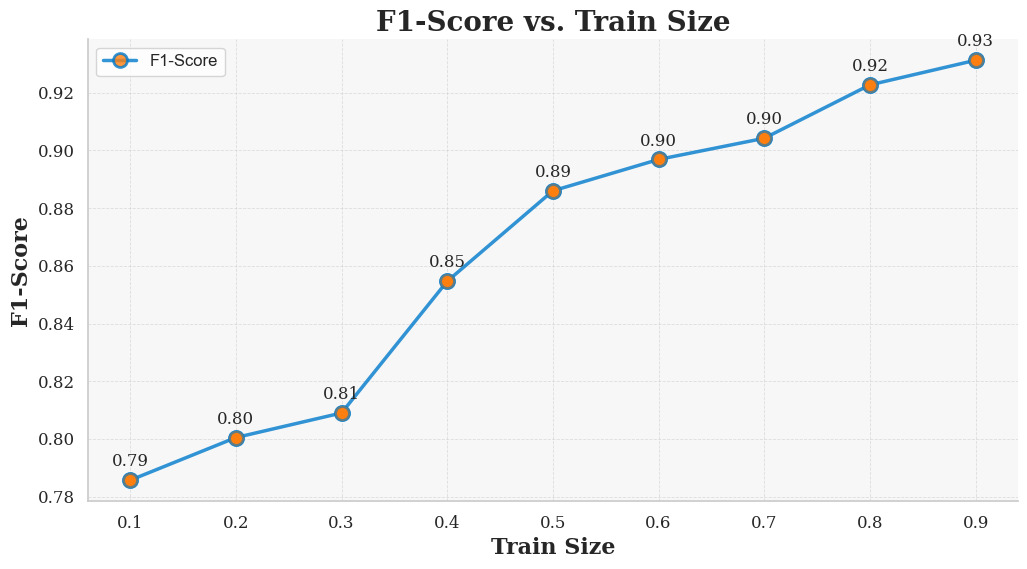

In [5]:
train_sizes = np.linspace(0.1, 0.9, 9)
performances_isolation = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=2009)

    clf = IsolationForest(n_estimators=173, contamination=0.08, random_state=2009, max_samples=1)
    outliers = clf.fit_predict(X_train)
    X_train = X_train[outliers == 1]
    Y_train = Y_train[outliers == 1]

    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_selected = X_train.drop(to_drop, axis=1)
    X_test_selected = X_test.drop(to_drop, axis=1)

    dtc_isolation = DecisionTreeClassifier(random_state=2009, criterion='gini')
    dtc_isolation.fit(X_train_selected, Y_train.values.ravel())

    Y_pred = dtc_isolation.predict(X_test_selected)
    performance_isolation = f1_score(Y_test, Y_pred)

    performances_isolation.append(performance_isolation)
    print(f"F1-Score for train size {train_size:.1f}: {performance_isolation}")

np.savetxt('7_dtc_isolation.txt', performances_isolation)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, performances_isolation, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('F1-Score', fontsize=16, fontweight='bold', family='serif')
plt.title('F1-Score vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(performances_isolation):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], performances_isolation[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['F1-Score'], fontsize=12)

sns.despine()

for i, txt in enumerate(performances_isolation):
    plt.plot(train_sizes[i], performances_isolation[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], performances_isolation[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
F1-Score for train size 0.1: 0.7404233870967742


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
F1-Score for train size 0.2: 0.7788353863381859


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1-Score for train size 0.7: 0.8692476260043828


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
F1-Score for train size 0.8: 0.8713513513513513


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
F1-Score for train size 0.9: 0.8590308370044053


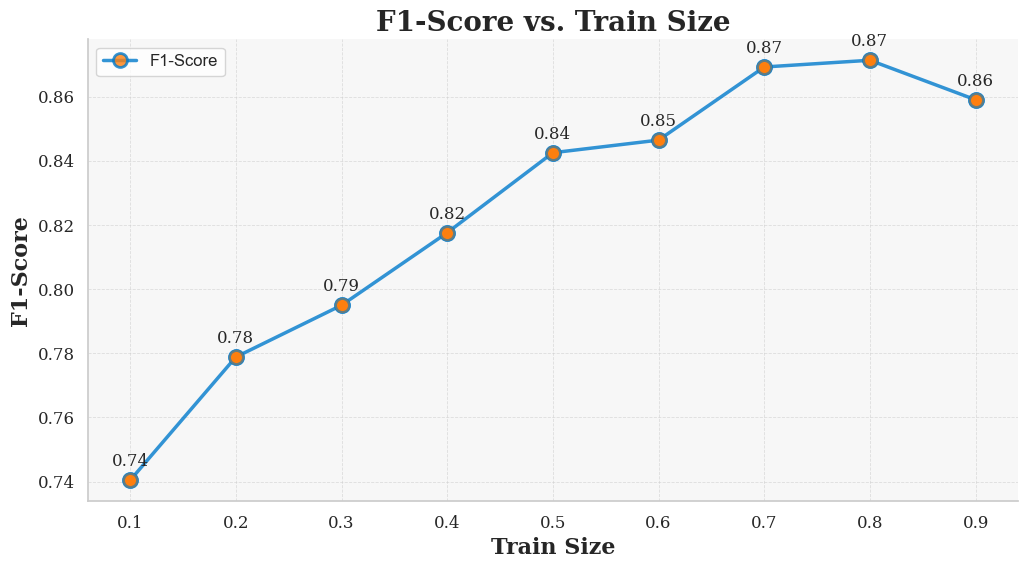

In [6]:
performances_lstm = []
seed = 274

for i in range(1, 10):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=i * 0.1, random_state=seed)

    X_train_reshaped = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_reshaped = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    model = Sequential()
    model.add(LSTM(11, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
    model.add(Dropout(0.01 * 4))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=1/7)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['f1_score'])

    model.fit(X_train_reshaped, Y_train, epochs=47, batch_size=10000, verbose=0)

    X_train_features = model.predict(X_train_reshaped)
    X_test_features = model.predict(X_test_reshaped)

    dtc_lstm = DecisionTreeClassifier(random_state=seed)
    dtc_lstm.fit(X_train_features, Y_train.values.ravel())

    Y_pred = dtc_lstm.predict(X_test_features)
    performance_lstm = f1_score(Y_test, Y_pred)

    performances_lstm.append(performance_lstm)
    print(f"F1-Score for train size {0.1 * i:.1f}: {performance_lstm}")

np.savetxt('7_dtc_lstm.txt', performances_lstm)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, performances_lstm, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('F1-Score', fontsize=16, fontweight='bold', family='serif')
plt.title('F1-Score vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(performances_lstm):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], performances_lstm[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['F1-Score'], fontsize=12)

sns.despine()

for i, txt in enumerate(performances_lstm):
    plt.plot(train_sizes[i], performances_lstm[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], performances_lstm[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

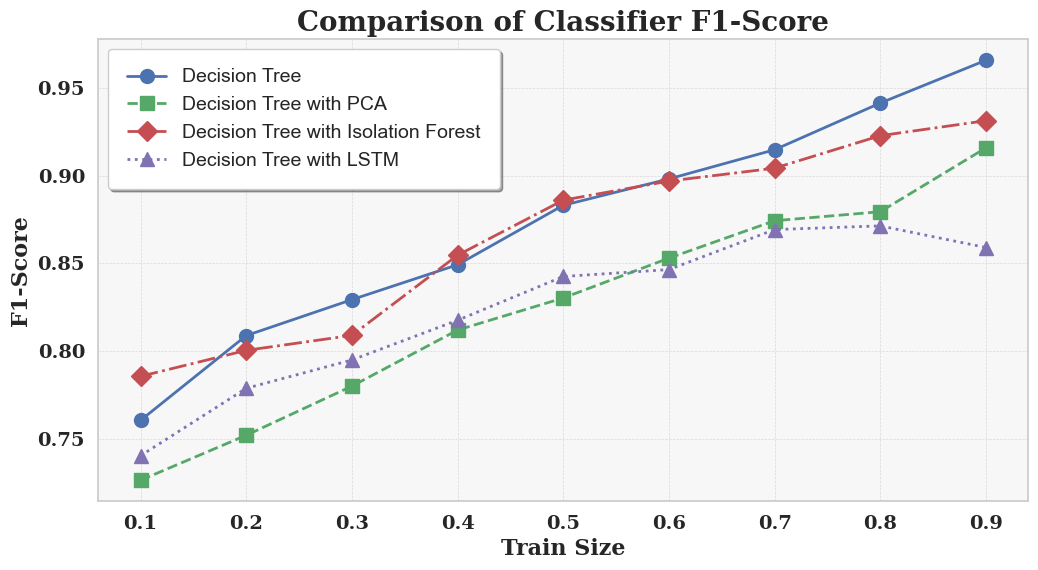

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

plt.plot(train_sizes, performances_dtc, marker='o', label='Decision Tree', linestyle='-', color='b', markersize=10, linewidth=2)
plt.plot(train_sizes, performances_pca, marker='s', label='Decision Tree with PCA', linestyle='--', color='g', markersize=10, linewidth=2)
plt.plot(train_sizes, performances_isolation, marker='D', label='Decision Tree with Isolation Forest', linestyle='-.', color='r', markersize=10, linewidth=2)
plt.plot(train_sizes, performances_lstm, marker='^', label='Decision Tree with LSTM', linestyle=':', color='m', markersize=10, linewidth=2)

plt.title('Comparison of Classifier F1-Score', size=20, fontweight='bold', family='serif')
plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('F1-Score', fontsize=16, fontweight='bold', family='serif')
plt.xticks(fontsize=14, fontweight='bold', family='serif')
plt.yticks(fontsize=14, fontweight='bold', family='serif')
plt.legend(loc='best', fontsize=14, frameon=True, fancybox=True, shadow=True, borderpad=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().set_facecolor('#f7f7f7')

plt.savefig('Images/7_Comparison_of_DT_classifier_F1-Scores.png')

plt.show()

In [8]:
joblib.dump(model_dtc, '7_DT_Model.joblib')
joblib.dump(dtc_pca, '7_DT_PCA_Model.joblib')
joblib.dump(dtc_isolation, '7_DT_Isolation_Model.joblib')
joblib.dump(dtc_lstm, '7_DT_LSTM_Model.joblib')

['7_DT_LSTM_Model.joblib']